In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df_1 = pd.read_csv("../Cleaned_data/Cleaned_Social_Engine_Users.csv")
df_1.head()

,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,23-10-2023,38963
1,user_b1p3wz81,"Munich, Germany",zh,06-05-2023,24644
2,user_jm2grmis,"Dubai, UAE",en,03-01-2023,45842
3,user_ykoqww5l,"Paris, France",fr,11-10-2023,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,23-05-2023,42908


In [4]:
df_2 = pd.read_csv("../Cleaned_data/Cleaned_Social_Engine_Posts.csv")
df_2.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,4488,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,789,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,YouTube,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,2247,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,2024-09-10 00:00:00,167,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,2024-05-31 00:00:00,4749,152,630


In [21]:
df_1.shape

(1500, 5)

In [22]:
df_2.shape

(12000, 8)

In [23]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   location         1500 non-null   object
 2   language         1500 non-null   object
 3   account_created  1500 non-null   object
 4   follower_count   1500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 58.7+ KB


In [24]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   post_id       12000 non-null  object
 1   user_id       12000 non-null  object
 2   platform      12000 non-null  object
 3   text_content  12000 non-null  object
 4   timestamp     12000 non-null  object
 5   likes         12000 non-null  int64 
 6   shares        12000 non-null  int64 
 7   comments      12000 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 750.1+ KB


In [25]:
users = df_1.copy()
posts = df_2.copy()

In [26]:
users['account_created'] = pd.to_datetime(users['account_created'], format='%d-%m-%Y')

In [27]:
users['account_created'].dtype

dtype('<M8[ns]')

In [28]:
posts['timestamp'] = pd.to_datetime(posts['timestamp'])

In [29]:
posts['timestamp'].dtype

dtype('<M8[ns]')

In [30]:
users[['City', 'Country']] = users['location'].str.split(',', n=1, expand=True)
users['City'] = users['City'].str.strip()
users['Country'] = users['Country'].str.strip()

In [31]:
posts['Post_date'] = posts['timestamp'].dt.date
posts['Post_time'] = posts['timestamp'].dt.time

In [33]:
posts['Post_day'] = posts['timestamp'].dt.day_name()
posts['Post_month'] = posts['timestamp'].dt.month

In [34]:
posts['total_engagement'] = posts['likes'] + posts['shares'] + posts['comments']

In [39]:
posts['timestamp'].max()

Timestamp('2025-12-04 20:36:17')

In [41]:
users['Account_age_days'] = (pd.Timestamp("2025-12-04") - users['account_created']).dt.days

In [44]:
print("\n--- POSTS numeric summary ---")
print(posts[["likes", "shares", "comments", "total_engagement"]].describe())


--- POSTS numeric summary ---
              likes        shares     comments  total_engagement
count  12000.000000  12000.000000  12000.00000      12000.000000
mean    2246.101833   1007.167167    504.34575       3757.614750
std     1656.469938    575.072282    288.68416       1786.876514
min    -4987.000000      0.000000      0.00000      -4590.000000
25%     1277.000000    510.000000    253.00000       2739.750000
50%     2247.000000   1018.000000    503.00000       3855.500000
75%     3450.000000   1501.000000    755.00000       4965.000000
max     5000.000000   2000.000000   1000.00000       7893.000000


In [46]:
print("\n--- USERS numeric summary ---")
print(users[["follower_count", "Account_age_days"]].describe())


--- USERS numeric summary ---
       follower_count  Account_age_days
count     1500.000000       1500.000000
mean     24964.019333        883.840667
std      14185.477457        106.502819
min        109.000000        704.000000
25%      12771.750000        790.000000
50%      24741.500000        886.000000
75%      37097.250000        977.000000
max      49944.000000       1068.000000


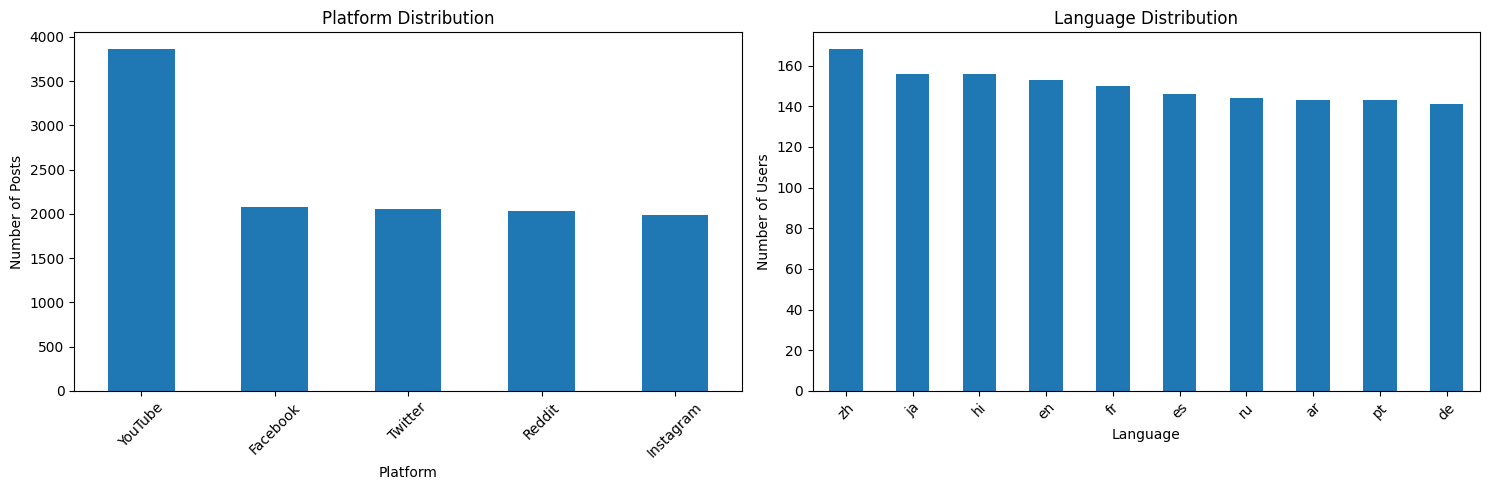

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

posts['platform'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Platform Distribution')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Number of Posts')
axes[0].tick_params(axis='x', rotation=45)

users['language'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Language Distribution')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Number of Users')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [48]:
print("\nPlatform counts:\n", posts["platform"].value_counts())
print("\nLanguage counts:\n", users["language"].value_counts())


Platform counts:
 platform
YouTube      3857
Facebook     2074
Twitter      2049
Reddit       2031
Instagram    1989
Name: count, dtype: int64

Language counts:
 language
zh    168
ja    156
hi    156
en    153
fr    150
es    146
ru    144
ar    143
pt    143
de    141
Name: count, dtype: int64


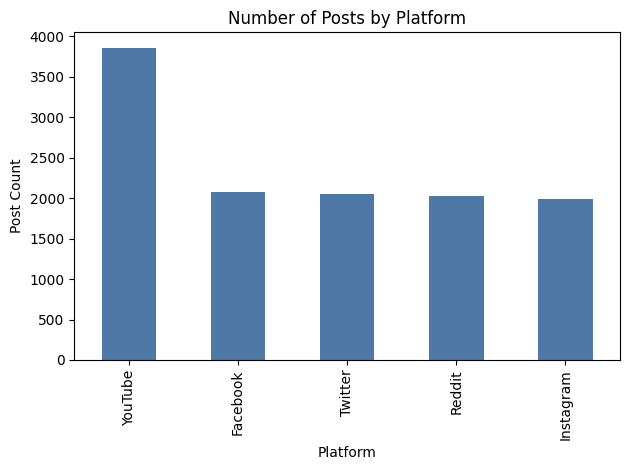

In [ ]:
plt.figure()
posts["platform"].value_counts().plot(kind="bar", color='#4E79A7')
plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Post Count")
plt.tight_layout()
plt.show()

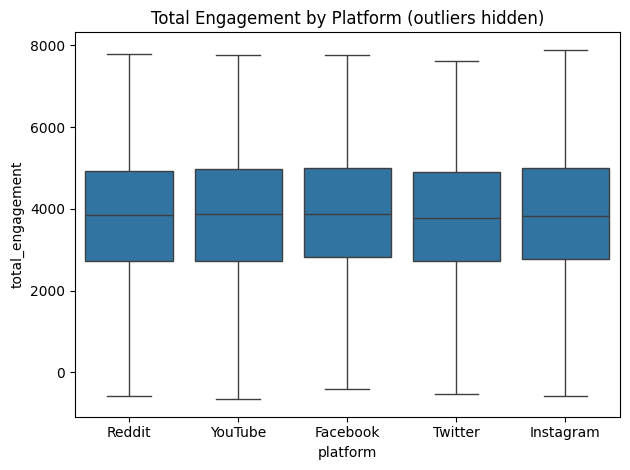

In [66]:
plt.figure()
sns.boxplot(data=posts, x="platform", y="total_engagement", showfliers=False)
plt.title("Total Engagement by Platform (outliers hidden)")
plt.tight_layout()
plt.show()

In [68]:
posts.columns

Index(['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes',
       'shares', 'comments', 'Post_date', 'Post_time', 'Post_day',
       'Post_month', 'total_engagement'],
      dtype='object')

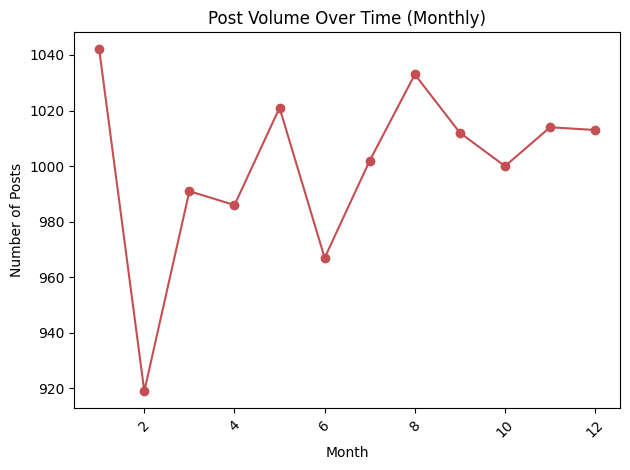

In [ ]:
monthly = posts.groupby(posts['timestamp'].dt.month).size()
plt.figure()
monthly.plot(kind="line", marker="o", color="#C44E52")
plt.title("Post Volume Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

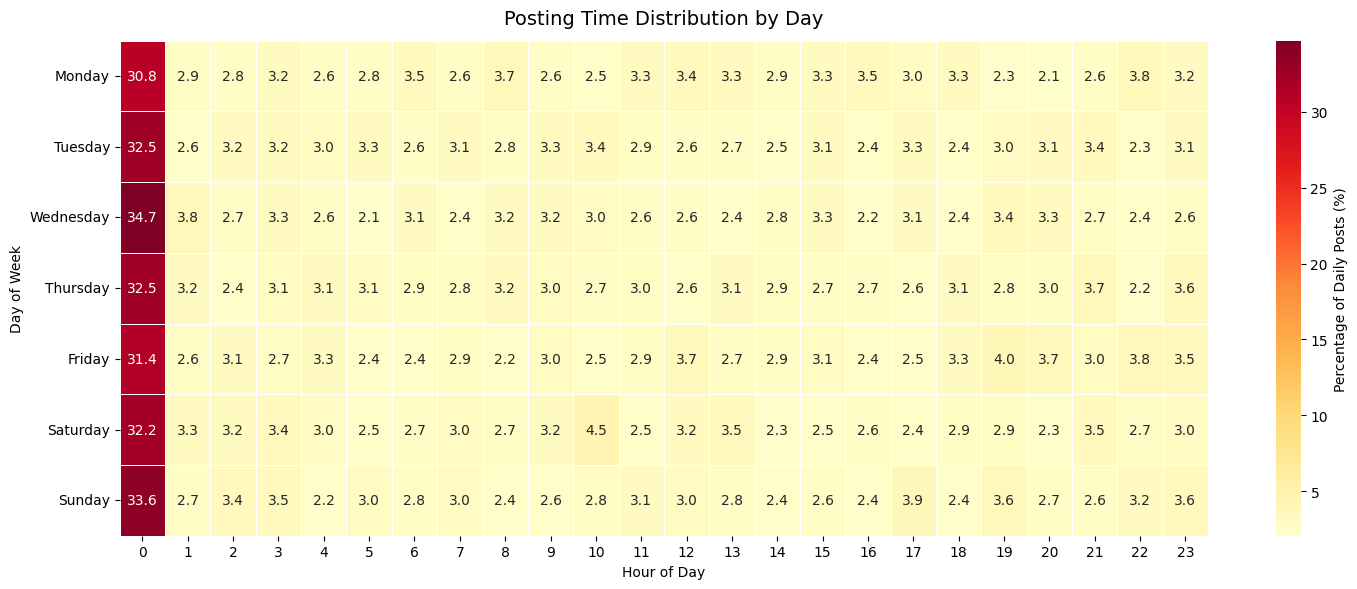

In [73]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(15, 6))

sns.heatmap(
    pivot_pct,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Percentage of Daily Posts (%)'}
)

plt.title('Posting Time Distribution by Day', fontsize=14, pad=12)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

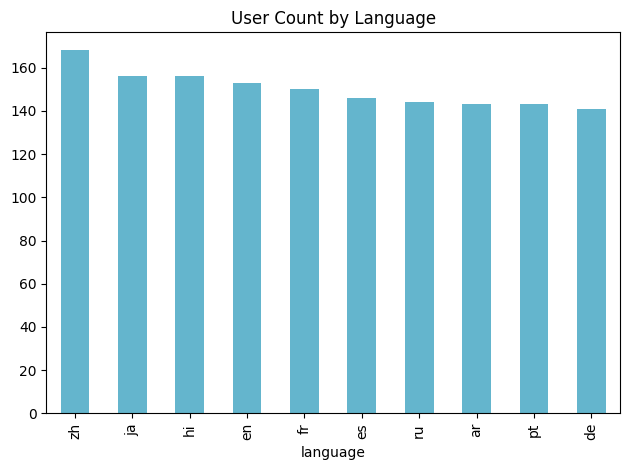

In [75]:
plt.figure()
users["language"].value_counts().plot(kind="bar", color="#64B5CD")
plt.title("User Count by Language")
plt.tight_layout()
plt.show()

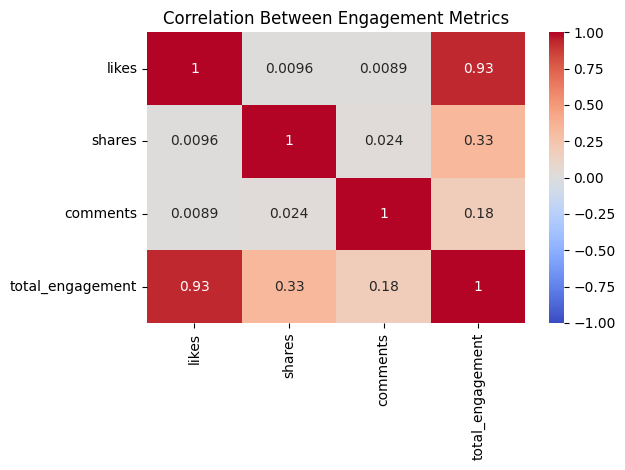

In [76]:
plt.figure()
corr = posts[["likes", "shares", "comments", "total_engagement"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Engagement Metrics")
plt.tight_layout()
plt.show()

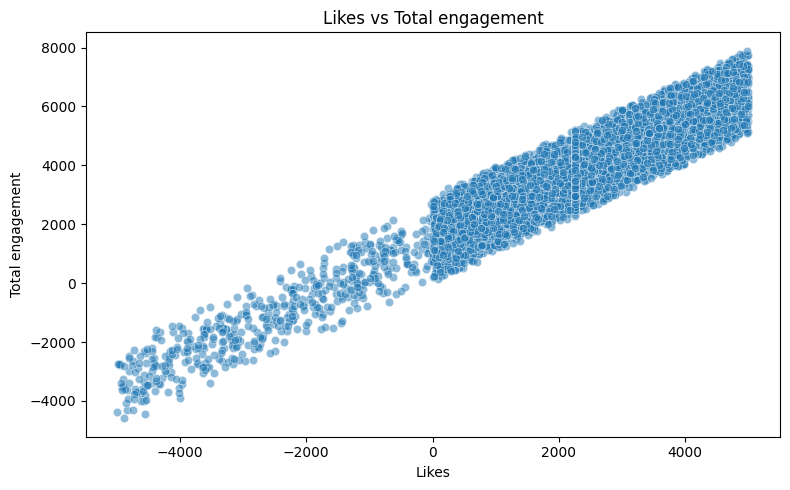

In [80]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=posts,x='likes', y='total_engagement',alpha=0.5)
plt.title('Likes vs Total engagement')
plt.xlabel('Likes')
plt.ylabel('Total engagement')
plt.tight_layout()
plt.show()

In [88]:
(posts['likes']<0).sum()

509

In [91]:
(((posts['likes']<0).sum()/posts.shape[0])*100).round(2)

4.24

In [92]:
(((posts['total_engagement']<0).sum()/posts.shape[0])*100).round(2)

2.96

In [96]:
posts = posts[(posts['likes'] >=0) & (posts['total_engagement'] >= 0)]

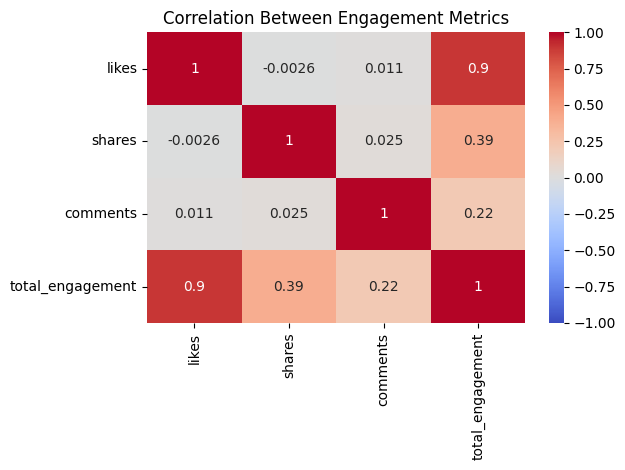

In [98]:
plt.figure()
corr = posts[["likes", "shares", "comments", "total_engagement"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Engagement Metrics")
plt.tight_layout()
plt.show()